In [3]:
import numpy as np
from dataclasses import dataclass
from typing import Optional
try:
    from scipy.integrate import quad
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False
from astropy import units as u
from astropy import constants as const

C_KMS = const.c.to(u.km/u.s).value

@dataclass
class CosmoParams:
    H0: float = 70.0            # [km/s/Mpc]
    Om0: float = 0.3            # Ω_m
    Ok0: float = 0.0            # Ω_k
    Or0: float = 0.0            # Ω_r (可忽略时设 0)
    # 暗能量状态方程：二选一
    w: Optional[float] = None      # 常数 w
    w0: float = -1.0            # CPL: w(a)=w0+wa(1-a)
    wa: float = 0.0

    def Ode0(self) -> float:
        return 1.0 - self.Om0 - self.Ok0 - self.Or0

def _rho_de_factor(z: float, cp: CosmoParams) -> float:
    """ρ_DE(z)/ρ_DE(0) 的无量纲演化因子。"""
    if cp.w is not None:  # 常数 w
        return (1.0 + z)**(3.0 * (1.0 + cp.w))
    # CPL: w(a)=w0+wa(1-a) => ρ_DE ∝ (1+z)^{3(1+w0+wa)} exp[-3 wa z/(1+z)]
    return (1.0 + z)**(3.0 * (1.0 + cp.w0 + cp.wa)) * np.exp(-3.0 * cp.wa * z / (1.0 + z))

def Ez(z: float, cp: CosmoParams) -> float:
    """E(z) = H(z)/H0."""
    de = cp.Ode0() * _rho_de_factor(z, cp)
    return np.sqrt(cp.Om0 * (1.0 + z)**3 + cp.Or0 * (1.0 + z)**4 + cp.Ok0 * (1.0 + z)**2 + de)

def _chi_quad(z: float, cp: CosmoParams) -> float:
    """无量纲共动径向距离 χ(z) = ∫_0^z dz'/E(z')."""
    if _HAS_SCIPY:
        val, _ = quad(lambda zp: 1.0 / Ez(zp, cp), 0.0, float(z), epsrel=1e-8, epsabs=0.0, limit=256)
        return val
    # 简单梯形积分后备方案
    zgrid = np.linspace(0.0, float(z), 4097)
    return np.trapz(1.0 / np.vectorize(Ez)(zgrid, cp), zgrid)

def _Sk(x: float, Ok0: float) -> float:
    """曲率函数 S_k(x)。注意这里的 x 是 √|Ω_k| χ。"""
    if abs(Ok0) < 1e-12:
        return x
    if Ok0 > 0.0:  # open, sinh
        return np.sinh(x)
    else:          # closed, sin
        return np.sin(x)

def D_M(z: float, cp: CosmoParams) -> float:
    """横向共动距离 D_M(z) [Mpc]."""
    chi = _chi_quad(z, cp)
    if abs(cp.Ok0) < 1e-12:
        return (C_KMS / cp.H0) * chi
    sqrtOk = np.sqrt(abs(cp.Ok0))
    return (C_KMS / cp.H0) * _Sk(sqrtOk * chi, cp.Ok0) / sqrtOk

def D_A(z: float, cp: CosmoParams) -> float:
    """角径距 D_A(0→z) [Mpc]."""
    return D_M(z, cp) / (1.0 + z)

def D_A12(z1: float, z2: float, cp: CosmoParams) -> float:
    """两红移间角径距 D_A(z1→z2) [Mpc], 需 z2>z1。"""
    if not (z2 > z1):
        raise ValueError("Require z2 > z1 for D_A12.")
    chi1 = _chi_quad(z1, cp)
    chi2 = _chi_quad(z2, cp)
    dchi = chi2 - chi1
    if abs(cp.Ok0) < 1e-12:
        DM12 = (C_KMS / cp.H0) * dchi
    else:
        sqrtOk = np.sqrt(abs(cp.Ok0))
        DM12 = (C_KMS / cp.H0) * _Sk(sqrtOk * dchi, cp.Ok0) / sqrtOk
    return DM12 / (1.0 + z2)

# ---- 封装常用距离 ----
def Dl(zl: float, cp: CosmoParams) -> float: return D_A(zl, cp)
def Ds(zs: float, cp: CosmoParams) -> float: return D_A(zs, cp)
def Dls(zl: float, zs: float, cp: CosmoParams) -> float: return D_A12(zl, zs, cp)

# =========================
# 1) 星系–星系透镜：R = Ds / Dls
# =========================
def galaxy_lens_distance_ratio(zl: float, zs: float, *,
                               H0: float, omega_m: float,
                               omega_k: float = 0.0, omega_r: float = 0.0,
                               w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回 R = D_s / D_ls （无量纲），仅含宇宙学部分。
    注：真实建模还需乘以结构因子 F(γ, β_ani, θ_ap/θ_E) 才能与(θ_E, σ_ap)组合。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    return Ds(zs, cp) / Dls(zl, zs, cp)

# =========================
# 2) 时延 AGN：D_dt = (1+zl) Dl Ds / Dls
# =========================
def time_delay_distance(zl: float, zs: float, *,
                        H0: float, omega_m: float,
                        omega_k: float = 0.0, omega_r: float = 0.0,
                        w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回时延距离 D_Δt [Mpc]： (1+zl) * Dl * Ds / Dls
    注意：观测上 D_Δt 还会被外会聚 κ_ext 等效缩放，建模需单独处理。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    return (1.0 + zl) * Dl(zl, cp) * Ds(zs, cp) / Dls(zl, zs, cp)

# =========================
# 3) 双源透镜：β_DSP = (D_ls2/D_s2) / (D_ls1/D_s1)
# =========================
def double_source_beta(zl: float, zs1: float, zs2: float, *,
                       H0: float, omega_m: float,
                       omega_k: float = 0.0, omega_r: float = 0.0,
                       w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回双源透镜的宇宙学量 β_DSP （无量纲）。
    要求 zl < zs1 < zs2。
    """
    if not (zl < zs1 < zs2):
        raise ValueError("Require zl < zs1 < zs2 for double-source lensing.")
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    num = Dls(zl, zs2, cp) / Ds(zs2, cp)
    den = Dls(zl, zs1, cp) / Ds(zs1, cp)
    return num / den

import numpy as np

def _as_float(x):
    # 确保传给积分器的是标量 float
    return float(np.asarray(x))

def galaxy_lens_distance_ratio_vec(
    zl, zs, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 R = Ds/Dls（与 zl、zs 广播后的形状一致）。
    不满足 zs>zl 的元素返回 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, zsA = np.broadcast_arrays(np.asarray(zl, float), np.asarray(zs, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, zsA, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zl_i, zs_i, o in it:
        zl_f, zs_f = _as_float(zl_i), _as_float(zs_i)
        if zs_f <= zl_f:
            o[...] = np.nan
        else:
            # o[...] = Ds(zs_f, cp) / Dls(zl_f, zs_f, cp)
            o[...] = Dls(zl_f, zs_f, cp) / Ds(zs_f, cp)
    return out

def time_delay_distance_vec(
    zl, zs, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 D_dt [Mpc] = (1+zl) * Dl * Ds / Dls。
    不满足 zs>zl 的元素返回 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, zsA = np.broadcast_arrays(np.asarray(zl, float), np.asarray(zs, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, zsA, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zl_i, zs_i, o in it:
        zl_f, zs_f = _as_float(zl_i), _as_float(zs_i)
        if zs_f <= zl_f:
            o[...] = np.nan
        else:
            o[...] = (1.0 + zl_f) * Dl(zl_f, cp) * Ds(zs_f, cp) / Dls(zl_f, zs_f, cp)
    return out

def double_source_beta_vec(
    zl, zs1, zs2, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 β_DSP = (D_ls2/D_s2)/(D_ls1/D_s1)。
    仅当 zl < zs1 < zs2 时有效，否则该元素 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, z1A, z2A = np.broadcast_arrays(np.asarray(zl, float),
                                        np.asarray(zs1, float),
                                        np.asarray(zs2, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, z1A, z2A, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['readonly'], ['writeonly']])
    for zl_i, z1_i, z2_i, o in it:
        zl_f, z1_f, z2_f = _as_float(zl_i), _as_float(z1_i), _as_float(z2_i)
        if not (zl_f < z1_f < z2_f):
            o[...] = np.nan
        else:
            num = Dls(zl_f, z2_f, cp) / Ds(z2_f, cp)
            den = Dls(zl_f, z1_f, cp) / Ds(z1_f, cp)
            o[...] = num / den
    return out



In [4]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List

# ====== 1) 包装：标量 R(zl,zs; cosmo) ======
def R_scalar(zl: float, zs: float, cosmo: Dict) -> float:
    # 只取 galaxy lens 的宇宙学部分：R = Ds/Dls
    return galaxy_lens_distance_ratio(float(zl), float(zs), **cosmo)

# ====== 2) 数值导数：∂ ln R / ∂ p ======
def dlnR_dp(zl: float, zs: float, cosmo: Dict, p: str,
            eps_rel: float = 1e-5, eps_abs: float = 1e-5) -> float:
    """
    对参数 p 求 ∂ ln R 的数值导数。
    对可为零或符号敏感的参量（如 w0, wa, omega_k），使用绝对步长；其余用相对步长。
    """
    cosmo_p = cosmo.copy()
    base = R_scalar(zl, zs, cosmo_p)
    if not np.isfinite(base) or base <= 0:
        return np.nan

    val = cosmo_p.get(p, None)
    # 选择步长
    if (val is None) or (abs(val) < 1e-12) or (p in ["w0", "wa", "omega_k"]):
        dp = eps_abs if p not in ["omega_m"] else max(eps_abs, 1e-6)
        p_minus, p_plus = (val - dp if val is not None else -dp), (val + dp if val is not None else dp)
    else:
        dp = abs(val) * eps_rel
        p_minus, p_plus = val - dp, val + dp

    # 边界防护（保证物理性）
    if p == "omega_m":
        p_minus = max(1e-6, p_minus); p_plus = max(2e-6, p_plus)
    if p == "w":   # 常数 w
        pass
    if p == "w0" or p == "wa":  # CPL
        pass
    if p == "omega_k":
        # 允许正负，但数值上别太极端
        p_minus = np.clip(p_minus, -0.5, 0.5)
        p_plus  = np.clip(p_plus,  -0.5, 0.5)

    # 中心差分
    cosmo_m = cosmo.copy(); cosmo_m[p] = p_minus
    cosmo_p2 = cosmo.copy(); cosmo_p2[p] = p_plus
    Rm = R_scalar(zl, zs, cosmo_m)
    Rp = R_scalar(zl, zs, cosmo_p2)
    if (Rm <= 0) or (Rp <= 0) or (not np.isfinite(Rm)) or (not np.isfinite(Rp)):
        return np.nan

    dlnR = (np.log(Rp) - np.log(Rm)) / (p_plus - p_minus)
    return float(dlnR)

def dlnDdt_dp(zl: float, zs: float, cosmo: dict, p: str,
              eps_rel: float = 1e-5, eps_abs: float = 1e-5) -> float:
    # analytic shortcut for H0:
    if p == "H0":
        H0 = float(cosmo.get("H0", 70.0))
        return -1.0 / H0  # since D_dt ∝ 1/H0

    base = Ddt_scalar(zl, zs, cosmo)
    if not np.isfinite(base) or base <= 0:
        return np.nan

    val = cosmo.get(p, None)
    if (val is None) or (abs(val) < 1e-12) or (p in ["w0", "wa", "omega_k"]):
        dp = eps_abs if p not in ["omega_m", "H0"] else max(eps_abs, 1e-6)
        p_minus = (val - dp) if (val is not None) else -dp
        p_plus  = (val + dp) if (val is not None) else  dp
    else:
        dp = abs(val) * eps_rel
        p_minus, p_plus = val - dp, val + dp

    if p == "omega_m":
        p_minus = max(1e-6, p_minus); p_plus = max(2e-6, p_plus)
    if p == "omega_k":
        p_minus = np.clip(p_minus, -0.5, 0.5); p_plus = np.clip(p_plus, -0.5, 0.5)
    if p == "H0":
        p_minus = max(1.0, p_minus); p_plus = max(2.0, p_plus)

    c_m = cosmo.copy(); c_m[p] = p_minus
    c_p = cosmo.copy(); c_p[p] = p_plus
    Dm = Ddt_scalar(zl, zs, c_m)
    Dp = Ddt_scalar(zl, zs, c_p)
    if (Dm <= 0) or (Dp <= 0) or (not np.isfinite(Dm)) or (not np.isfinite(Dp)):
        return np.nan
    return float((np.log(Dp) - np.log(Dm)) / (p_plus - p_minus))

# ====== 3) Fisher：单点 & 累积（保持不变，这里仅贴一遍方便对齐）======
def fisher_single(zl: float, zs: float, cosmo: Dict, params: List[str], sigma_frac: float) -> np.ndarray:
    """单个 (zl,zs) 的 Fisher（len(params) × len(params)）"""
    J = np.array([dlnR_dp(zl, zs, cosmo, p) for p in params], dtype=float)  # ∂lnR/∂p
    if not np.all(np.isfinite(J)):
        return np.zeros((len(params), len(params)))
    F = np.outer(J, J) / (sigma_frac**2)
    return F

def fisher_cumulative(zl_arr: np.ndarray, zs: float, cosmo: Dict, params: List[str], sigma_frac: float) -> np.ndarray:
    """把一个 zs 下所有 zl 的 Fisher 相加"""
    F = np.zeros((len(params), len(params)), dtype=float)
    for zl in zl_arr:
        if zl <= 0 or zl >= zs:
            continue
        F += fisher_single(float(zl), float(zs), cosmo, params, sigma_frac)
    return F

# ====== 4) zl 网格（保持不变）======
def zl_grid_for_zs(zs: float, dz: float = 0.004) -> np.ndarray:
    n = max(1, int(np.floor(zs / dz)))
    eps = 1e-6 * max(1.0, zs)
    return np.linspace(eps, zs - eps, n)

# ====== 5) 画“局部敏感度”曲线：S_p/sigma_lnR vs zl（8 条曲线/每个参数）======
def plot_local_sensitivity(zs_list, param, cosmo, sigma_frac=0.05, dz=0.004):
    """
    画 sensitivity ≡ |∂lnR/∂p| / σ_lnR 的曲线（越高越敏感）。
    每个 z_s 一条：横轴 z_l, 纵轴 sensitivity。
    """
    plt.figure(figsize=(8,5))
    for zs in zs_list:
        zls = zl_grid_for_zs(zs, dz=dz)
        sens = []
        for zl in zls:
            d = dlnR_dp(zl, zs, cosmo, param)
            if np.isfinite(d):
                sens.append(abs(d) / max(sigma_frac, 1e-30))
            else:
                sens.append(np.nan)
        plt.plot(zls, sens, label=f"z_s={zs:.1f}")

    plt.yscale('log')
    plt.xlabel(r"$z_l$")
    plt.ylabel(rf"Sensitivity: $|\partial \ln R/\partial {param}|/\sigma_{{\ln R}}$")
    plt.title(rf"Local sensitivity for {param}  (σ_R/R = {sigma_frac:.1%})")
    plt.grid(alpha=0.3)
    plt.legend(ncol=2)
    
    # —— 仅当限制的参数是 omega_m 时，加下限 0.1 —— 
    if param == "omega_m":
        ymin, ymax = plt.ylim()
        # 只修改下限，保留当前上限
        plt.ylim(bottom=0.5, top=max(ymax, 0.2)) 

    plt.tight_layout()
    plt.show()


# ====== 6) 画“累积边际化敏感度”曲线：1/σ_marg vs z_s ======
def plot_cumulative_marginalized(zs_list, params, cosmo, sigma_frac=0.05, dz=0.004, param_to_plot=None):
    """
    对每个 z_s，把 [0, z_s) 的所有 z_l Fisher 相加 => F。
    取协方差 C = F^{-1}，并画 1/sqrt(C_ii) 作为“边际化敏感度”（越高越敏感）。
    """
    zs_list = list(zs_list)
    if param_to_plot is not None:
        idx = params.index(param_to_plot)
        ys = []
        for zs in zs_list:
            F = fisher_cumulative(zl_grid_for_zs(zs, dz=dz), zs, cosmo, params, sigma_frac)
            if np.linalg.matrix_rank(F) < len(params):
                ys.append(np.nan)
            else:
                C = np.linalg.inv(F)
                sigma_i = np.sqrt(C[idx, idx])
                ys.append(1.0 / sigma_i if sigma_i > 0 else np.nan)
        plt.figure(figsize=(6,4))
        plt.plot(zs_list, ys, marker='o')
        plt.yscale('log')
        plt.xlabel(r"$z_s$")
        plt.ylabel(rf"Sensitivity: $1/\sigma({param_to_plot})$ (marginalized)")
        plt.title(rf"Cumulative marginalized sensitivity (σ_R/R = {sigma_frac:.1%})")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(7,5))
        for j, p in enumerate(params):
            ys = []
            for zs in zs_list:
                F = fisher_cumulative(zl_grid_for_zs(zs, dz=dz), zs, cosmo, params, sigma_frac)
                if np.linalg.matrix_rank(F) < len(params):
                    ys.append(np.nan)
                else:
                    C = np.linalg.inv(F)
                    sigma_j = np.sqrt(C[j, j])
                    ys.append(1.0 / sigma_j if sigma_j > 0 else np.nan)
            plt.plot(zs_list, ys, marker='o', label=p)
        plt.yscale('log')
        plt.xlabel(r"$z_s$")
        plt.ylabel("Sensitivity: $1/\\sigma(\\cdot)$  (marginalized)")
        plt.title(rf"Cumulative marginalized sensitivity vs $z_s$ (σ_R/R = {sigma_frac:.1%})")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()





In [42]:
import numpy as np
import matplotlib.pyplot as plt

# --------- generic 2x2 plotter (for R or D_dt) ----------
def _plot_sensitivity_vs_zl_quad(zs_list, cosmo, sigma_frac, dz, deriv_fn,
                                 title_prefix, ylabel_math, outputname):
    """
    Make a 2x2 figure for params ['omega_m','omega_k','w0','wa'].
    Each subplot shows sensitivity(z_l) for multiple z_s in zs_list.
      deriv_fn(zl, zs, cosmo, p) -> ∂ ln O / ∂ p
      ylabel_math: LaTeX for observable, e.g. r"D_s/D_{ls}" or r"D_{{\\Delta t}}"
    """
    params = ["omega_m", "omega_k", "w0", "wa"]
    titles = [r"$\Omega_m$", r"$\Omega_k$", r"$w_0$", r"$w_a$"]

    # Reserve space on the right for a vertical legend column
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=False, sharey=False)
    axes = axes.ravel()

    for ax, p, ttl in zip(axes, params, titles):
        for zs in zs_list:
            zls = zl_grid_for_zs(zs, dz=dz)   # (0, zs)
            sens = []
            for zl in zls:
                d = deriv_fn(zl, zs, cosmo, p)
                sens.append(abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan)
            y = np.asarray(sens, float)
            m = np.isfinite(zls) & np.isfinite(y)
            if np.any(m):
                ax.plot(zls[m], y[m], lw=1.6, label=fr"$z_s={zs:.1f}$")

        ax.set_yscale('log')
        ax.grid(alpha=0.3)
        ax.set_title(ttl)
        ax.set_xlabel(r"$z_l$",fontsize=15,)
        ax.set_ylabel(fr"Sensitivity: $|\partial \ln {ylabel_math}/\partial p|/\sigma_{{\ln {ylabel_math}}}$")

        # Optional y-limits
        ymin, ymax = ax.get_ylim()
        if p == "omega_m":
            ax.set_ylim(bottom=1.)
        elif p == "omega_k":
            ax.set_ylim(bottom=1.)
        elif p == "w0":
            ax.set_ylim(bottom=0.001)
        elif p == "wa":
            ax.set_ylim(bottom=1e-5)

    # Build a single legend and place it outside on the right
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        if h:
            handles, labels = h, l
            break
    if handles:
        # leave room on the right and put legend there
        fig.subplots_adjust(right=0.80)  # shrink axes area to 80% width
        fig.legend(handles, labels,
                   loc="center left", bbox_to_anchor=(0.82, 0.5),fontsize=15,
                   ncol=1, frameon=False, borderaxespad=0.0)

    # Title + tighter layout (respecting the reserved right margin)
    fig.suptitle(
        fr"{title_prefix}: sensitivity vs $z_l$  ($\sigma_{{{ylabel_math}}}/{{{ylabel_math}}}$ = {sigma_frac:.1%})",
        y=0.98, fontsize=13
    )
    plt.tight_layout(rect=[0.03, 0.03, 0.80, 0.94])  # [left, bottom, right, top]
    plt.savefig(outputname, dpi=300)
    plt.show()


# --------- 1) Distance ratio R = Ds / Dls  (H0 cancels) ----------
def plot_sensitivity_R_quad(zs_list, cosmo_cpl, sigma_frac=0.05, dz=0.004):
    """
    4 subplots (Ωm, Ωk, w0, wa): sensitivity of R=Ds/Dls vs z_l, for each z_s in zs_list.
    Use CPL {w0, wa}. If you pass a wCDM dict, make sure NOT to include 'w' here; use w0=-1, wa=0.
    """
    # enforce CPL keys
    cosmo = dict(H0=cosmo_cpl.get("H0", 70.0),
                 omega_m=cosmo_cpl.get("omega_m", 0.3),
                 omega_k=cosmo_cpl.get("omega_k", 0.0),
                 w0=cosmo_cpl.get("w0", -1.0),
                 wa=cosmo_cpl.get("wa", 0.0))
    cosmo.pop("w", None)  # ensure CPL branch

    def deriv_fn(zl, zs, c, p):
        return dlnR_dp(zl, zs, c, p)

    _plot_sensitivity_vs_zl_quad(
        zs_list, cosmo, sigma_frac, dz, deriv_fn,
        title_prefix=r"Distance ratio $R=D_s/D_{ls}$",
        ylabel_math=r"D_s/D_{ls}",
        outputname = r"fisher_dis_ratio01.png"
    )

# --------- 2) Time-delay distance D_dt = (1+zl) Dl Ds / Dls ----------
def plot_sensitivity_Ddt_quad(zs_list, cosmo_cpl, sigma_frac=0.05, dz=0.004):
    """
    4 subplots (Ωm, Ωk, w0, wa): sensitivity of D_dt vs z_l, for each z_s in zs_list.
    Uses CPL {w0, wa}. (You may still pass a wCDM dict; we convert to CPL with w0,wa.)
    """
    cosmo = dict(H0=cosmo_cpl.get("H0", 70.0),
                 omega_m=cosmo_cpl.get("omega_m", 0.3),
                 omega_k=cosmo_cpl.get("omega_k", 0.0),
                 w0=cosmo_cpl.get("w0", -1.0),
                 wa=cosmo_cpl.get("wa", 0.0))
    cosmo.pop("w", None)

    def deriv_fn(zl, zs, c, p):
        return dlnDdt_dp(zl, zs, c, p)

    # Note: in f-strings, write D_{{\Delta t}} to escape braces correctly
    _plot_sensitivity_vs_zl_quad(
        zs_list, cosmo, sigma_frac, dz, deriv_fn,
        title_prefix=r"Time-delay distance $D_{\Delta t}$",
        ylabel_math=r"D_{{\Delta t}}",
        outputname = r"fisher_time-delay01.png"
    )


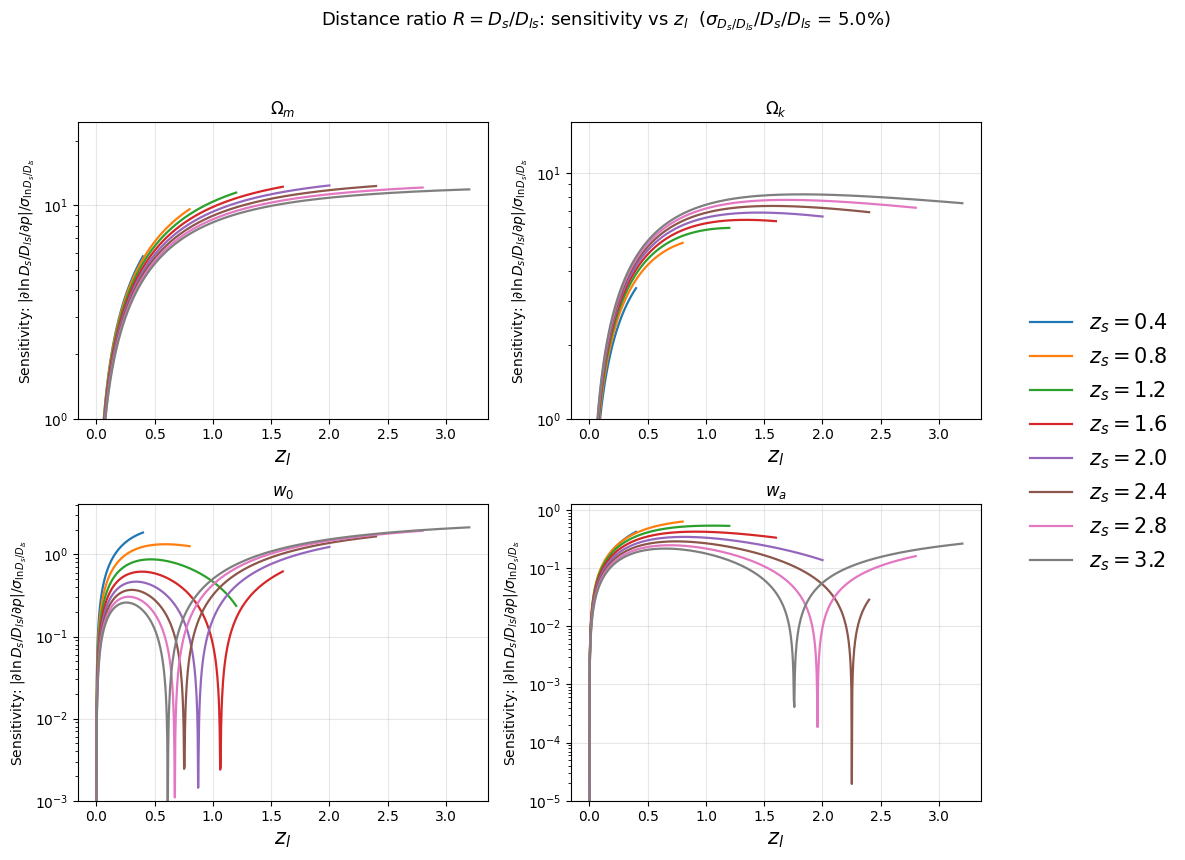

In [43]:
zs_list   = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8,3.2]
cosmo_cpl = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)
sigma_frac = 0.05
dz = 0.004

plot_sensitivity_R_quad(zs_list, cosmo_cpl, sigma_frac=sigma_frac, dz=dz)
# plot_sensitivity_Ddt_quad(zs_list, cosmo_cpl, sigma_frac=sigma_frac, dz=dz)


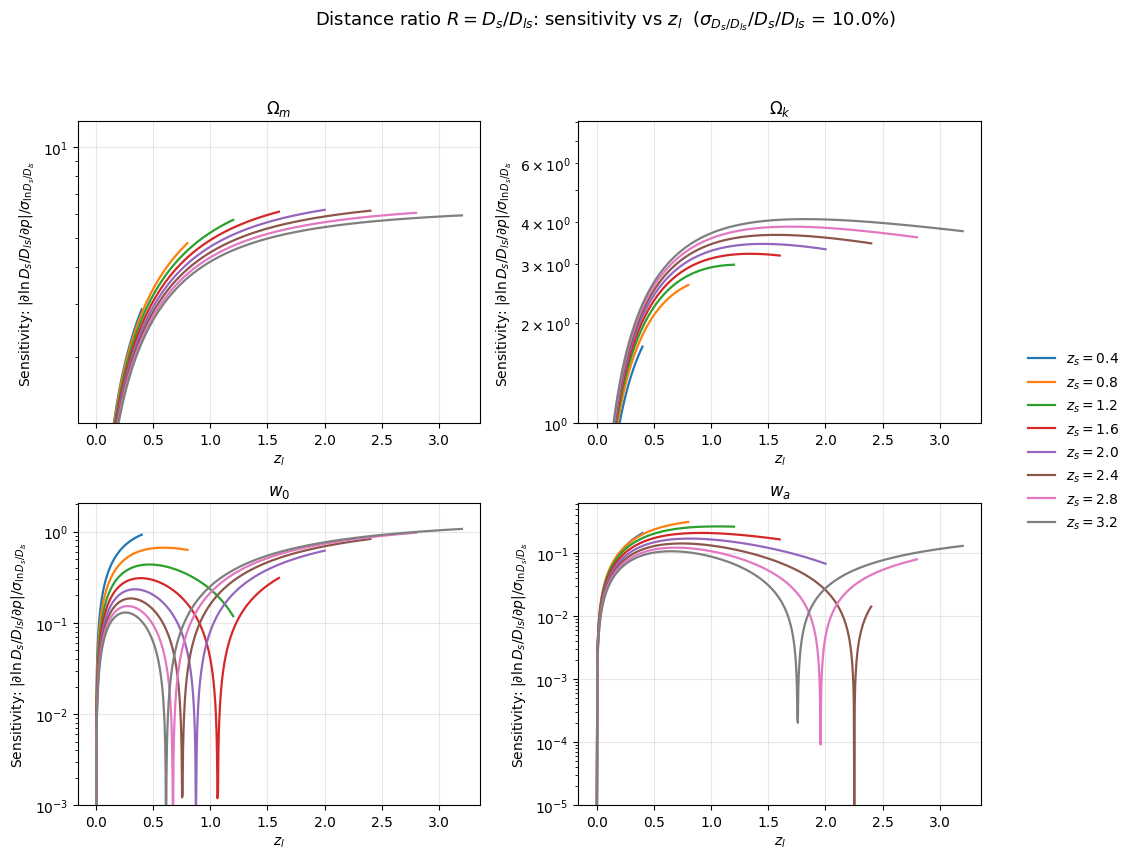

In [37]:
zs_list   = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8,3.2]
cosmo_cpl = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)
sigma_frac = 0.1
dz = 0.004

plot_sensitivity_R_quad(zs_list, cosmo_cpl, sigma_frac=sigma_frac, dz=dz)
# plot_sensitivity_Ddt_quad(zs_list, cosmo_cpl, sigma_frac=sigma_frac, dz=dz)


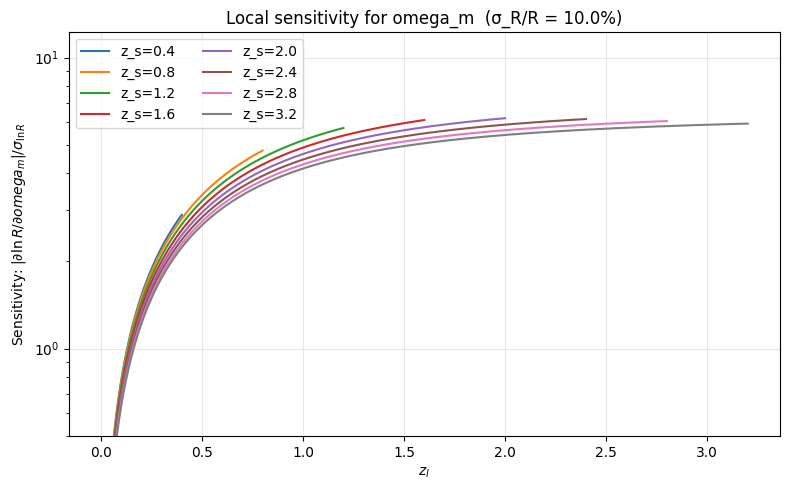

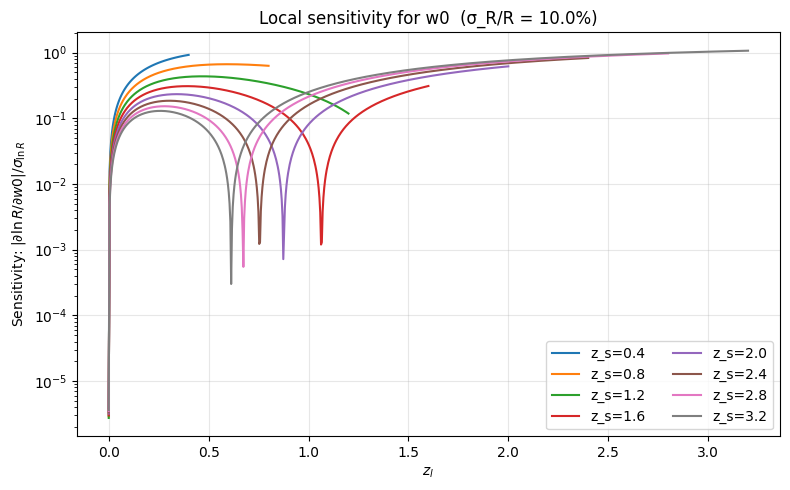

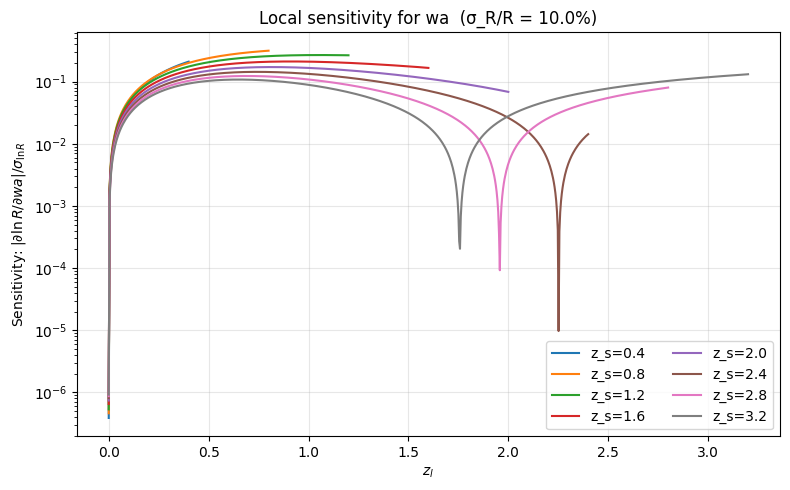

In [5]:
# ====== 7) 示例调用 ======
if __name__ == "__main__":
    # 选择模型：常数 w（传 w），或 CPL（不传 w，传 w0, wa）
    # 例：wCDM
    cosmo_wcdm = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=-1.0)
    # 例：CPL
    cosmo_cpl  = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)

    zs_list = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]
    sigma_frac = 0.1   # 假设单个 R 的相对误差 5%，可改为 0.02 等
    dz = 0.004          # 你的网格步长

    # # —— 画“局部约束能力”曲线（每个参数各 8 条曲线）——
    # # 对 Ωm：
    plot_local_sensitivity(zs_list, param="omega_m", cosmo=cosmo_wcdm, sigma_frac=sigma_frac, dz=dz)
    # # 对 常数 w（若你用 wCDM）：
    # plot_local_sensitivity(zs_list, param="w",       cosmo=cosmo_wcdm, sigma_frac=sigma_frac, dz=dz)
    # # 或者对 CPL: w0, wa（若你用 CPL）
    plot_local_sensitivity(zs_list, param="w0",      cosmo=cosmo_cpl,  sigma_frac=sigma_frac, dz=dz)
    plot_local_sensitivity(zs_list, param="wa",      cosmo=cosmo_cpl,  sigma_frac=sigma_frac, dz=dz)

    # # —— 可选：画“累积边际化”约束（把一个 zs 下所有 zl 相加）——
    # # 多参数同时边际化（示例：Ωm 与 w）：
    # params_wcdm = ["omega_m", "w"]
    # plot_cumulative_marginalized(zs_list, params=params_wcdm, cosmo=cosmo_wcdm,
    #                              sigma_frac=sigma_frac, dz=dz, param_to_plot=None)
    # # 或只画某一个参数的累积边际化误差：
    # # plot_cumulative_marginalized(zs_list, params=params_wcdm, cosmo=cosmo_wcdm,
    # #                              sigma_frac=sigma_frac, dz=dz, param_to_plot="omega_m")

In [6]:
zl01 = np.linspace(0.0,1.6,9)[1:-1]
zl01

array([0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4])

In [ ]:
w_list = np.linspace(-2.0,0.0,201)[1:-1]
cosmo = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=-1.0)
zl01 = np.linspace(0.0,1.6,9)[1:-1]
zs01 = 1.6

R_ratio = []


for i in range(len(w_list)):
    cosmo_check = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=w_list[i]) 
    R_ratio.append(galaxy_lens_distance_ratio(zl01, zs01, **cosmo)/galaxy_lens_distance_ratio(zl01, zs01, **cosmo_check))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 假设已有这三个等长数组：
# w_list, R_ratio, Ddt_ratio = ...

def prep_xy(x, y):
    """按 y 排序，并去除 NaN/inf。返回 x_sorted, y_sorted。"""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    idx = np.argsort(y)
    x, y = x[idx], y[idx]
    m = np.isfinite(x) & np.isfinite(y)
    return x[m], y[m]

x1, y1 = prep_xy(R_ratio,  w_list)   # R_ratio vs w
x2, y2 = prep_xy(Ddt_ratio, w_list)  # Ddt_ratio vs w
x3, y3 = prep_xy(Doub_beta, w_list)  # Ddt_ratio vs w

plt.figure(figsize=(7,5))
plt.plot(x1, y1, marker='o', linestyle='-', label='R_ratio (Ds/Dls)')
plt.plot(x2, y2, marker='s', linestyle='--', label='Ddt_ratio (time-delay)')
plt.plot(x3, y3, marker='.', linestyle='--', label='Double source plane')
plt.axvline(1.0, linestyle=':', linewidth=1, alpha=0.7)  # 可选：ratio=1 参考线

plt.xlabel('ratio')
plt.ylabel('w')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


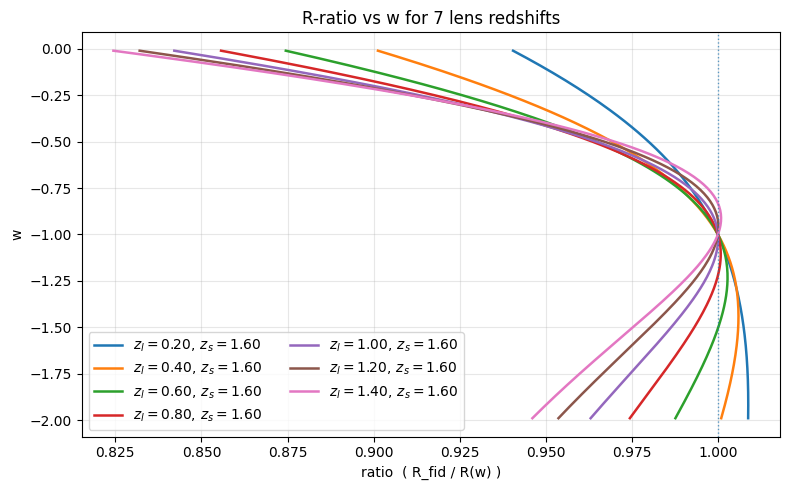

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# grids
w_list = np.linspace(-2.0, 0.0, 201)[1:-1]   # vary w
cosmo_fid = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=-1.0)
zl01 = np.linspace(0.0, 1.6, 9)[1:-1]        # 7 lens redshifts
zs01 = 1.6                                    # single source redshift

# R_ratio[j, i] = R_fid(zl_j) / R_wi(zl_j)
R_ratio = np.empty((len(zl01), len(w_list)), dtype=float)

for j, zl in enumerate(zl01):
    # fiducial R once per zl
    R_fid = galaxy_lens_distance_ratio(zl, zs01, **cosmo_fid)
    for i, w in enumerate(w_list):
        cosmo_check = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=w)
        R_var = galaxy_lens_distance_ratio(zl, zs01, **cosmo_check)
        R_ratio[j, i] = R_fid / R_var

# --- plot: 7 curves (one per zl) ---
plt.figure(figsize=(8,5))
for j, zl in enumerate(zl01):
    x = R_ratio[j]                    # ratio
    y = w_list                        # w
    m = np.isfinite(x) & np.isfinite(y)
    plt.plot(x[m], y[m], lw=1.8, label=fr"$z_l={zl:.2f},\, z_s={zs01:.2f}$")

plt.axvline(1.0, linestyle=':', linewidth=1, alpha=0.7)  # ratio=1 guide
plt.xlabel("ratio  ( R_fid / R(w) )")
plt.ylabel("w")
plt.title("R-ratio vs w for 7 lens redshifts")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


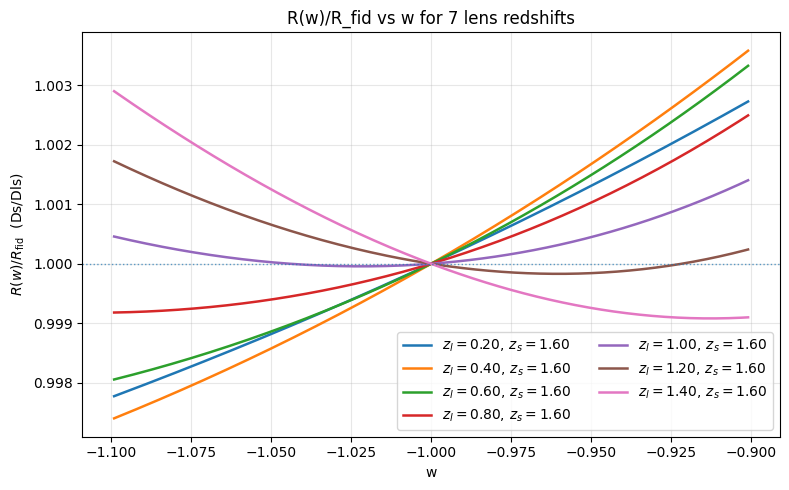

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# grids
w_list = np.linspace(-1.1, -0.9, 201)[1:-1]   # vary w (x-axis)
cosmo_fid = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=-1.0)
zl01 = np.linspace(0.0, 1.6, 9)[1:-1]        # 7 lens redshifts
zs01 = 1.6                                    # single source redshift

# R_curve[j, i] = R_var(zl_j; w_i) / R_fid(zl_j)
R_curve = np.empty((len(zl01), len(w_list)), dtype=float)

for j, zl in enumerate(zl01):
    R_fid = galaxy_lens_distance_ratio(zl, zs01, **cosmo_fid)
    for i, w in enumerate(w_list):
        cosmo_w = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=w)
        R_var = galaxy_lens_distance_ratio(zl, zs01, **cosmo_w)
        R_curve[j, i] = R_var / R_fid   # note: inverse of previous ratio

# --- plot: x = w, y = R_var/R_fid (7 curves, one per z_l) ---
plt.figure(figsize=(8,5))
for j, zl in enumerate(zl01):
    y = R_curve[j]                  # R(w)/R_fid
    x = w_list                      # w
    m = np.isfinite(x) & np.isfinite(y)
    plt.plot(x[m], y[m], lw=1.8, label=fr"$z_l={zl:.2f},\, z_s={zs01:.2f}$")

plt.axhline(1.0, linestyle=':', linewidth=1, alpha=0.7)  # y=1 guide
plt.xlabel("w")
plt.ylabel(r"$R(w)/R_{\rm fid}$  (Ds/Dls)")
plt.title("R(w)/R_fid vs w for 7 lens redshifts")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------- generic tripanel-style plotter (2x2 actually) ----------
def _plot_sensitivity_vs_zl_quad(zs_list, cosmo, sigma_frac, dz, deriv_fn, title_prefix):
    """
    Internal helper to make a 2x2 subplot figure for params ['omega_m','omega_k','w0','wa'].
    Each subplot shows sensitivity(z_l) for multiple z_s in zs_list.
      deriv_fn(zl, zs, cosmo, p) -> ∂ ln O / ∂ p
    """
    params = ["omega_m", "omega_k", "w0", "wa"]
    titles = [r"$\Omega_m$", r"$\Omega_k$", r"$w_0$", r"$w_a$"]

    fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=False, sharey=False)
    axes = axes.ravel()

    for ax, p, ttl in zip(axes, params, titles):
        for zs in zs_list:
            zls = zl_grid_for_zs(zs, dz=dz)   # (0, zs)
            sens = []
            for zl in zls:
                d = deriv_fn(zl, zs, cosmo, p)
                sens.append(abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan)
            y = np.asarray(sens, float)
            m = np.isfinite(zls) & np.isfinite(y)
            if np.any(m):
                ax.plot(zls[m], y[m], lw=1.6, label=fr"$z_s={zs:.1f}$")

        ax.set_yscale('log')
        ax.grid(alpha=0.3)
        ax.set_title(ttl)
        ax.set_xlabel(r"$z_l$")
        ax.set_ylabel(r"Sensitivity: $|\partial \ln \mathcal{O}/\partial p|/\sigma_{\ln \mathcal{O}}$")

        # Optional y-limits similar to your styling
        ymin, ymax = ax.get_ylim()
        if p == "omega_m":
            ax.set_ylim(bottom=0.05, top=max(ymax, 0.5))
        elif p == "omega_k":
            ax.set_ylim(bottom=0.01)
        elif p == "w0":
            ax.set_ylim(bottom=0.001)
        elif p == "wa":
            ax.set_ylim(bottom=1e-5)

        # Tighter layout for many legends: put one global legend later
    # Global legend assembled from the first axes that has labels
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        if h:
            handles, labels = h, l
            break
    if handles:
        fig.legend(handles, labels, loc="lower center", ncol=min(len(labels), 5),
                   frameon=False, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(fr"{title_prefix}: sensitivity vs $z_l$  ($\sigma_{{\mathcal O}}/\mathcal O$ = {sigma_frac:.1%})",
                 y=1.02, fontsize=13)
    fig.tight_layout()
    plt.show()

# --------- 1) Distance ratio R = Ds / Dls  (H0 cancels) ----------
def plot_sensitivity_R_quad(zs_list, cosmo_cpl, sigma_frac=0.05, dz=0.004):
    """
    4 subplots (Ωm, Ωk, w0, wa): sensitivity of R=Ds/Dls vs z_l, for each z_s in zs_list.
    Use CPL {w0, wa}. If you pass a wCDM dict, make sure to NOT include 'w' here; use w0=-1, wa=0.
    """
    # enforce CPL keys
    cosmo = dict(H0=cosmo_cpl.get("H0", 70.0),
                 omega_m=cosmo_cpl.get("omega_m", 0.3),
                 omega_k=cosmo_cpl.get("omega_k", 0.0),
                 w0=cosmo_cpl.get("w0", -1.0),
                 wa=cosmo_cpl.get("wa", 0.0))
    cosmo.pop("w", None)  # ensure CPL branch in your distance code

    def deriv_fn(zl, zs, c, p):
        # you already defined dlnR_dp previously
        return dlnR_dp(zl, zs, c, p)

    _plot_sensitivity_vs_zl_quad(zs_list, cosmo, sigma_frac, dz, deriv_fn,
                                 title_prefix=r"Distance ratio $R=D_s/D_{ls}$")

# --------- 2) Time-delay distance D_dt = (1+zl) Dl Ds / Dls ----------
def plot_sensitivity_Ddt_quad(zs_list, cosmo_cpl, sigma_frac=0.05, dz=0.004):
    """
    4 subplots (Ωm, Ωk, w0, wa): sensitivity of D_dt vs z_l, for each z_s in zs_list.
    Uses CPL {w0, wa}. (You may still pass a wCDM dict; we convert to CPL with w0,wa.)
    """
    cosmo = dict(H0=cosmo_cpl.get("H0", 70.0),
                 omega_m=cosmo_cpl.get("omega_m", 0.3),
                 omega_k=cosmo_cpl.get("omega_k", 0.0),
                 w0=cosmo_cpl.get("w0", -1.0),
                 wa=cosmo_cpl.get("wa", 0.0))
    cosmo.pop("w", None)

    def deriv_fn(zl, zs, c, p):
        # you already defined dlnDdt_dp previously
        return dlnDdt_dp(zl, zs, c, p)

    _plot_sensitivity_vs_zl_quad(zs_list, cosmo, sigma_frac, dz, deriv_fn,
                                 title_prefix=r"Time-delay distance $D_{\Delta t}$")


In [ ]:
if __name__ == "__main__":
    # Base cosmologies
    cosmo_wcdm = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=-1.0)
    cosmo_cpl  = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)

    zs_list = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]
    sigma_frac = 0.10
    dz = 0.004

    # Distance ratio (use CPL keys; this disables the 'w' branch implicitly)
    plot_sensitivity_R_quad(zs_list, cosmo_cpl, sigma_frac=sigma_frac, dz=dz)

    # Time-delay distance
    # plot_sensitivity_Ddt_quad(zs_list, cosmo_cpl, sigma_frac=sigma_frac, dz=dz)
